In [1]:
# =============================================
# IMPORTS
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# =============================================
# LOAD DATA
# =============================================
df = pd.read_csv("customerchurn.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



=== Data Exploration ===

1. Null values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

2. Duplicates: 0

3. Fixing TotalCharges column...

4. Class distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64
Imbalance ratio: 2.76:1


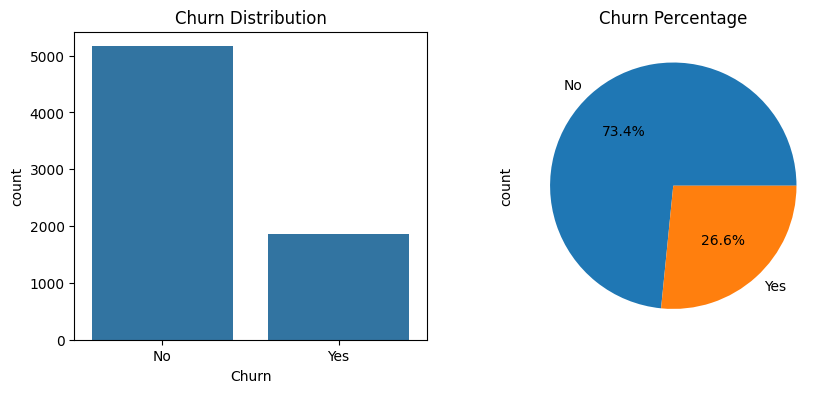

In [2]:
# =============================================
# DATA EXPLORATION - FIXED
# =============================================
print("\n=== Data Exploration ===")

# 1. Check for nulls
print("\n1. Null values:")
print(df.isnull().sum())

# 2. Check for duplicates
print(f"\n2. Duplicates: {df.duplicated().sum()}")

# 3. Fix TotalCharges column
print("\n3. Fixing TotalCharges column...")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])  # Drop rows with NaN in TotalCharges

# 4. Check class imbalance
print("\n4. Class distribution:")
print(df['Churn'].value_counts())
print(f"Imbalance ratio: {df['Churn'].value_counts()[0]/df['Churn'].value_counts()[1]:.2f}:1")

# Visualize
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')

plt.subplot(1, 2, 2)
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Churn Percentage')
plt.show()

In [3]:
# =============================================
# DATA HANDLING - FIXED
# =============================================
print("\n=== Data Handling ===")

# 1. Drop unnecessary columns
print("\n1. Dropping columns...")
df = df.drop(['customerID', 'Contract'], axis=1)  # Keep TotalCharges!

# 2. Label encode all categorical columns
print("\n2. Label encoding...")
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
        print(f"  Encoded: {col}")

# 3. Check data types
print("\n3. Data types after encoding:")
print(df.dtypes.value_counts())


=== Data Handling ===

1. Dropping columns...

2. Label encoding...
  Encoded: gender
  Encoded: Partner
  Encoded: Dependents
  Encoded: PhoneService
  Encoded: MultipleLines
  Encoded: InternetService
  Encoded: OnlineSecurity
  Encoded: OnlineBackup
  Encoded: DeviceProtection
  Encoded: TechSupport
  Encoded: StreamingTV
  Encoded: StreamingMovies
  Encoded: PaperlessBilling
  Encoded: PaymentMethod
  Encoded: Churn

3. Data types after encoding:
int64      17
float64     2
Name: count, dtype: int64


In [4]:
# =============================================
# TRAIN-TEST SPLIT - FIXED (No data leakage!)
# =============================================
print("\n=== Train-Test Split ===")

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

print(f"\nTraining class distribution:")
print(y_train.value_counts(normalize=True))


=== Train-Test Split ===
X_train: (5625, 18), y_train: (5625,)
X_test: (1407, 18), y_test: (1407,)

Training class distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64


In [5]:
# =============================================
# SCALING - FIXED (Critical fix!)
# =============================================
print("\n=== Scaling Data ===")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit ONLY on training
X_test_scaled = scaler.transform(X_test)        # Transform test with training scaler

print("✓ Data scaled properly (no data leakage)")


=== Scaling Data ===
✓ Data scaled properly (no data leakage)


In [6]:
# =============================================
# HANDLE CLASS IMBALANCE
# =============================================
print("\n=== Handling Class Imbalance ===")

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {np.bincount(y_train)}")
print(f"After SMOTE: {np.bincount(y_train_res)}")


=== Handling Class Imbalance ===
Before SMOTE: [4130 1495]
After SMOTE: [4130 4130]


In [7]:
# =============================================
# MODEL DEFINITION
# =============================================
print("\n=== Model Definition ===")

# Define models with optimized parameters
models = {
    'Logistic Regression': LogisticRegression(
        C=0.01, 
        penalty='l2',
        max_iter=1000,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8,
        criterion='gini',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.01,
        max_depth=4,
        random_state=42,
        eval_metric='logloss'
    )
}

print("✓ Models defined with optimized parameters")


=== Model Definition ===
✓ Models defined with optimized parameters


In [8]:
# =============================================
# TRAIN MODELS
# =============================================
print("\n=== Training Models ===")

predictions = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_res, y_train_res)
    predictions[name] = model.predict(X_test_scaled)


=== Training Models ===
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...


In [9]:
# =============================================
# EVALUATE MODELS
# =============================================
print("\n=== Model Evaluation ===")

results = []
for name, y_pred in predictions.items():
    f1 = f1_score(y_test, y_pred)
    results.append({
        'Model': name,
        'F1 Score': f1
    })
    print(f"{name:20} F1 Score: {f1:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
print("\n" + "="*40)
print("FINAL RANKING:")
print("="*40)
print(results_df.to_string(index=False))

# Select best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n✅ Best Model: {best_model_name}")


=== Model Evaluation ===
Logistic Regression  F1 Score: 0.6121
Decision Tree        F1 Score: 0.5776
Random Forest        F1 Score: 0.5906
XGBoost              F1 Score: 0.6101

FINAL RANKING:
              Model  F1 Score
Logistic Regression  0.612069
            XGBoost  0.610092
      Random Forest  0.590571
      Decision Tree  0.577626

✅ Best Model: Logistic Regression


In [10]:
# =============================================
# DETAILED EVALUATION OF BEST MODEL
# =============================================
print("\n=== Detailed Evaluation of Best Model ===")

y_pred_best = predictions[best_model_name]

print("Classification Report:")
print(classification_report(y_test, y_pred_best, 
                           target_names=['No Churn', 'Churn']))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_best)
print(f"\nConfusion Matrix:")
print(f"[[TN:{cm[0,0]} FP:{cm[0,1]}]")
print(f" [FN:{cm[1,0]} TP:{cm[1,1]}]]")

# Feature Importance (if available)
if hasattr(best_model, 'feature_importances_'):
    print("\n=== Feature Importance ===")
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("Top 10 Features:")
    print(feature_importance.head(10).to_string(index=False))


=== Detailed Evaluation of Best Model ===
Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.74      0.81      1033
       Churn       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407


Confusion Matrix:
[[TN:763 FP:270]
 [FN:90 TP:284]]


In [11]:
# =============================================
# SIMPLE DEPLOYMENT FUNCTION
# =============================================
print("\n=== Deployment Function ===")

def predict_customer_churn(features_dict):
    """
    Predict churn for a single customer
    features_dict: Dictionary with feature names as keys
    """
    # Create a DataFrame with the input
    input_df = pd.DataFrame([features_dict])
    
    # Ensure all columns are present
    for col in X.columns:
        if col not in input_df.columns:
            input_df[col] = 0  # Fill missing with default
    
    # Reorder columns to match training
    input_df = input_df[X.columns]
    
    # Scale the input
    input_scaled = scaler.transform(input_df)
    
    # Make prediction
    prediction = best_model.predict(input_scaled)[0]
    prediction_proba = best_model.predict_proba(input_scaled)[0]
    
    # Return result
    result = {
        'churn': 'Yes' if prediction == 1 else 'No',
        'churn_probability': float(prediction_proba[1]),
        'stay_probability': float(prediction_proba[0])
    }
    
    return result

# Test the function
print("\nTest prediction:")
test_customer = {
    'tenure': 15,
    'MonthlyCharges': 70.0,
    'TotalCharges': 1050.0,
    'PhoneService': 1,
    'InternetService': 1
}

result = predict_customer_churn(test_customer)
print(f"Prediction: {result}")


=== Deployment Function ===

Test prediction:
Prediction: {'churn': 'Yes', 'churn_probability': 0.6453081454741705, 'stay_probability': 0.3546918545258295}
